# Laboratorio 1 — Análisis de Componentes Principales (PCA)

**Problema:** representar Iris, Old Faithful y Wholesale Customers en menos dimensiones, cuantificar la varianza conservada e interpretar las combinaciones de variables. Cada caso mantiene el mismo razonamiento y sus propias unidades. Las etiquetas o categorías externas se utilizan únicamente para describir proyecciones, nunca para ajustar PCA.

**Ruta:** pregunta → datos → exploración → variables → transformación → PCA → número de componentes → cargas y scores → reconstrucción → interpretación.


## Objetivos de aprendizaje

- Explicar la diferencia entre observación, variable original, componente, score y carga.
- Examinar scree plot y varianza acumulada para tomar una decisión explícita de reducción.
- Reconocer la pérdida de información y la influencia de escala, asimetría y variables correlacionadas.


## Fundamento del método

PCA proyecta las observaciones en direcciones ortogonales que maximizan sucesivamente la varianza. `components_` contiene las direcciones; `explained_variance_ratio_` mide la proporción de varianza estandarizada capturada; `transform` devuelve scores por observación. Una componente es una combinación lineal de variables, no un grupo de observaciones. El signo de cada dirección puede invertirse sin alterar la solución.


## Configuración

Importamos las herramientas y fijamos un umbral docente de 80 % de varianza acumulada. El umbral depende del propósito de análisis: no garantiza conservar toda señal relevante.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

VARIANCE_TARGET = 0.80
plt.style.use('seaborn-v0_8-whitegrid')


## Caso 1: Iris

Cada fila es una flor con cuatro medidas de sépalo y pétalo en cm. ¿Cuántas direcciones resumen la variación morfológica sin utilizar la especie para ajustar?


### Carga y calidad de los datos

Examinamos forma, valores faltantes y rangos antes de escoger y transformar variables. No se eliminan duplicados sin revisar su significado.

In [2]:
iris = load_iris(as_frame=True)
iris_data = iris.data.copy()
iris_external = iris.target.copy()
print('Dimensiones:', iris_data.shape)
print('Faltantes:', iris_data.isna().sum().to_dict())
display(iris_data.head())
display(iris_data.describe().round(2))


Dimensiones: (150, 4)
Faltantes: {'sepal length (cm)': 0, 'sepal width (cm)': 0, 'petal length (cm)': 0, 'petal width (cm)': 0}


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Selección de variables

Elegimos mediciones continuas que describen el fenómeno. Excluimos etiquetas, identificadores y categorías externas del ajuste; las categorías se pueden usar después para colorear el gráfico.

In [3]:
iris_features = list(iris_data.columns)
iris_X = iris_data[iris_features].copy()
display(iris_X.corr().round(2))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


**Decisión de preparación:** conservamos las unidades para interpretarlas, pero estandarizamos antes del PCA para equilibrar las contribuciones de variables con dispersiones diferentes.

### Escala y representación para el modelo

Ajustamos el escalador únicamente sobre las variables elegidas. La tabla original se conserva para interpretar los resultados.

In [4]:
iris_processed = iris_X.copy()
iris_scaler = StandardScaler()
iris_scaled = iris_scaler.fit_transform(iris_processed)
display(pd.DataFrame(iris_scaled, columns=iris_features).describe().loc[['mean', 'std']].round(2))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


### Ajuste del PCA completo

`fit_transform` calcula las direcciones y proyecta las observaciones. Ajustamos inicialmente todas las componentes para observar la varianza de cada una antes de decidir cuántas retener.

In [5]:
iris_pca = PCA()
iris_scores = iris_pca.fit_transform(iris_scaled)
iris_ratio = iris_pca.explained_variance_ratio_
iris_cumulative = np.cumsum(iris_ratio)
iris_variance = pd.DataFrame({'componente': np.arange(1, len(iris_ratio)+1), 'varianza': iris_ratio, 'acumulada': iris_cumulative})
display(iris_variance.round(3))


,componente,varianza,acumulada
0,1,0.730,0.730
1,2,0.229,0.958
2,3,0.037,0.995
3,4,0.005,1.000


### Selección gráfica de componentes

El scree plot muestra ganancias individuales y la curva acumulada señala el menor número de componentes que alcanza el 80 %. Esta elección orienta una reducción; si importa una variable de baja varianza, se debe revisar con el objetivo de análisis.

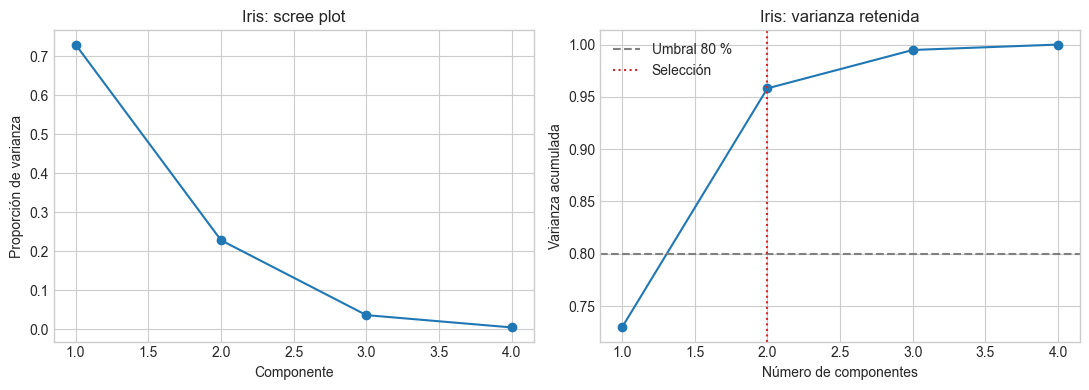

Componentes retenidas: 2 Varianza conservada: 0.958


In [6]:
iris_n = int(np.searchsorted(iris_cumulative, VARIANCE_TARGET) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(iris_variance.componente, iris_ratio, marker='o')
axes[0].set(xlabel='Componente', ylabel='Proporción de varianza', title='Iris: scree plot')
axes[1].plot(iris_variance.componente, iris_cumulative, marker='o')
axes[1].axhline(VARIANCE_TARGET, color='gray', linestyle='--', label='Umbral 80 %')
axes[1].axvline(iris_n, color='tab:red', linestyle=':', label='Selección')
axes[1].set(xlabel='Número de componentes', ylabel='Varianza acumulada', title='Iris: varianza retenida')
axes[1].legend();plt.tight_layout();plt.show()
print('Componentes retenidas:', iris_n, 'Varianza conservada:', round(iris_cumulative[iris_n-1], 3))


### Cargas y estructura de las variables

Las direcciones (`components_.T`) dan los coeficientes sobre las variables estandarizadas. Su magnitud relativa identifica variables influyentes y los signos **relativos dentro de una componente** distinguen covariación y contraste. No asignamos significado automático basándonos únicamente en el ranking absoluto.

,PC1,PC2
sepal length (cm),0.521,0.377
sepal width (cm),-0.269,0.923
petal length (cm),0.580,0.024
petal width (cm),0.565,0.067


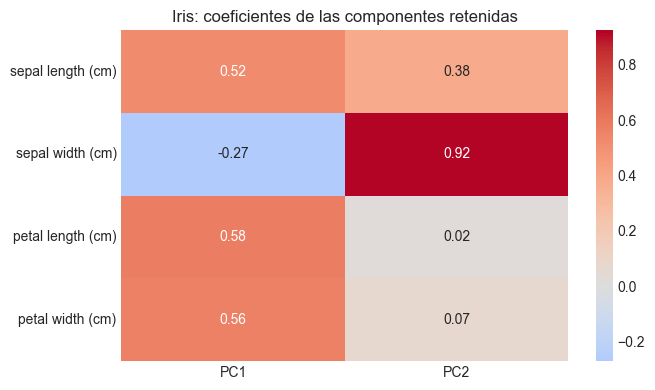

In [7]:
iris_loadings = pd.DataFrame(iris_pca.components_.T, index=iris_features, columns=[f'PC{j+1}' for j in range(len(iris_ratio))])
display(iris_loadings.iloc[:, :iris_n].round(3))
fig, ax = plt.subplots(figsize=(max(7,iris_n*1.4),4))
sns.heatmap(iris_loadings.iloc[:, :iris_n], annot=True, center=0, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Iris: coeficientes de las componentes retenidas');plt.tight_layout();plt.show()


### Scores y proyección en dos dimensiones

El gráfico PC1–PC2 es una vista 2D aunque el umbral requiera más componentes. Las categorías, cuando existen, solo colorean filas tras el ajuste; una separación aparente no valida una clasificación.

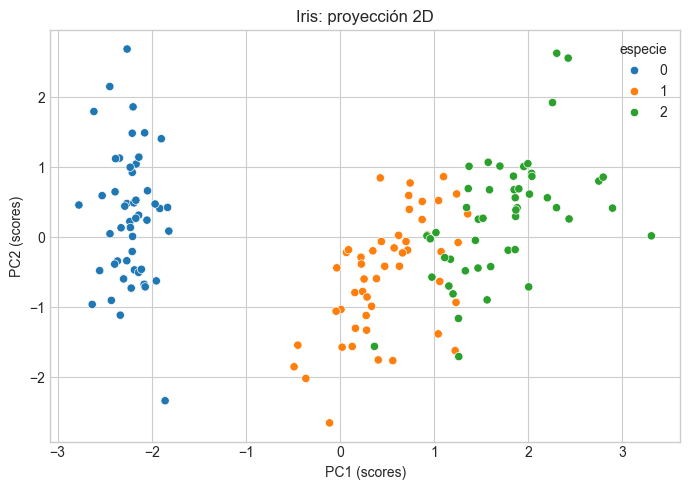

In [8]:
iris_projection = pd.DataFrame(iris_scores[:, :2], columns=['PC1','PC2'])
iris_projection['especie'] = iris_external.to_numpy()
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=iris_projection, x='PC1', y='PC2', hue='especie', palette='tab10', ax=ax)
ax.set(xlabel='PC1 (scores)', ylabel='PC2 (scores)', title='Iris: proyección 2D')
plt.tight_layout();plt.show()


### Pérdida al reconstruir

Reconstruimos desde las componentes retenidas y medimos el error cuadrático promedio **en escala estandarizada**. La proyección de dos componentes para graficar y la representación retenida para reconstrucción pueden ser distintas.

In [9]:
iris_reduced = iris_scores[:, :iris_n]
iris_approx = iris_reduced @ iris_pca.components_[:iris_n, :] + iris_pca.mean_
iris_mse = np.mean((iris_scaled - iris_approx)**2)
print('Error cuadrático de reconstrucción (escala estandarizada):', round(iris_mse, 4))


Error cuadrático de reconstrucción (escala estandarizada): 0.0419


**Interpretación guiada de Iris:** compara el porcentaje retenido y el error de reconstrucción con la pregunta inicial. Lee en la tabla de cargas las variables con signo concordante o contrario dentro de cada componente y evita inferir el significado solo por magnitudes absolutas. La importancia de cada dirección depende de la transformación aplicada.

## Caso 2: Old Faithful

Cada fila describe una erupción mediante duración y espera (min). ¿Cuánta variación conjunta se concentra en una dirección? PCA con dos variables resume y rota; no permite una gran reducción dimensional. La fuente requiere conexión.


### Carga y calidad de los datos

Examinamos forma, valores faltantes y rangos antes de escoger y transformar variables. No se eliminan duplicados sin revisar su significado.

In [10]:
faithful_url = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv'
faithful_data = pd.read_csv(faithful_url).drop(columns='rownames')
print('Dimensiones:', faithful_data.shape)
print('Faltantes:', faithful_data.isna().sum().to_dict())
display(faithful_data.head())
display(faithful_data.describe().round(2))


Dimensiones: (272, 2)
Faltantes: {'eruptions': 0, 'waiting': 0}


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


,eruptions,waiting
count,272.00,272.00
mean,3.49,70.90
std,1.14,13.59
min,1.60,43.00
25%,2.16,58.00
50%,4.00,76.00
75%,4.45,82.00
max,5.10,96.00


### Selección de variables

Elegimos mediciones continuas que describen el fenómeno. Excluimos etiquetas, identificadores y categorías externas del ajuste; las categorías se pueden usar después para colorear el gráfico.

In [11]:
faithful_features = ['eruptions', 'waiting']
faithful_X = faithful_data[faithful_features].copy()
display(faithful_X.corr().round(2))


,eruptions,waiting
eruptions,1.0,0.9
waiting,0.9,1.0


**Decisión de preparación:** conservamos las unidades para interpretarlas, pero estandarizamos antes del PCA para equilibrar las contribuciones de variables con dispersiones diferentes.

### Escala y representación para el modelo

Ajustamos el escalador únicamente sobre las variables elegidas. La tabla original se conserva para interpretar los resultados.

In [12]:
faithful_processed = faithful_X.copy()
faithful_scaler = StandardScaler()
faithful_scaled = faithful_scaler.fit_transform(faithful_processed)
display(pd.DataFrame(faithful_scaled, columns=faithful_features).describe().loc[['mean', 'std']].round(2))


,eruptions,waiting
mean,0.0,0.0
std,1.0,1.0


### Ajuste del PCA completo

`fit_transform` calcula las direcciones y proyecta las observaciones. Ajustamos inicialmente todas las componentes para observar la varianza de cada una antes de decidir cuántas retener.

In [13]:
faithful_pca = PCA()
faithful_scores = faithful_pca.fit_transform(faithful_scaled)
faithful_ratio = faithful_pca.explained_variance_ratio_
faithful_cumulative = np.cumsum(faithful_ratio)
faithful_variance = pd.DataFrame({'componente': np.arange(1, len(faithful_ratio)+1), 'varianza': faithful_ratio, 'acumulada': faithful_cumulative})
display(faithful_variance.round(3))


,componente,varianza,acumulada
0,1,0.95,0.95
1,2,0.05,1.00


### Selección gráfica de componentes

El scree plot muestra ganancias individuales y la curva acumulada señala el menor número de componentes que alcanza el 80 %. Esta elección orienta una reducción; si importa una variable de baja varianza, se debe revisar con el objetivo de análisis.

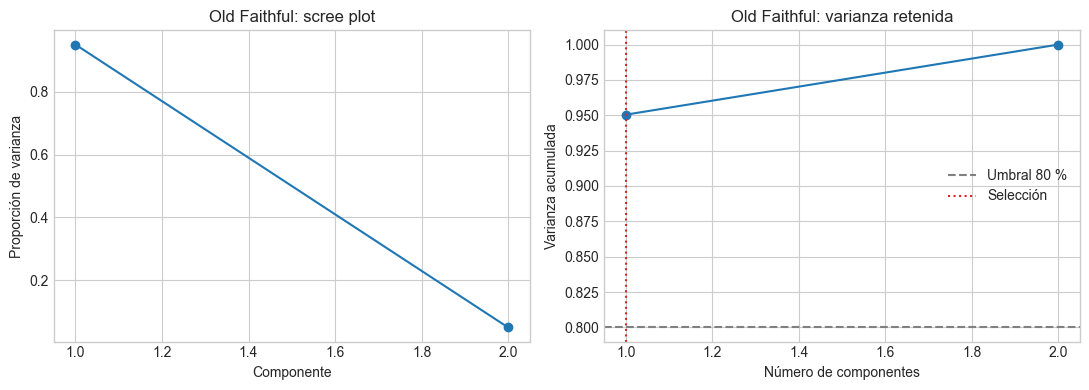

Componentes retenidas: 1 Varianza conservada: 0.95


In [14]:
faithful_n = int(np.searchsorted(faithful_cumulative, VARIANCE_TARGET) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(faithful_variance.componente, faithful_ratio, marker='o')
axes[0].set(xlabel='Componente', ylabel='Proporción de varianza', title='Old Faithful: scree plot')
axes[1].plot(faithful_variance.componente, faithful_cumulative, marker='o')
axes[1].axhline(VARIANCE_TARGET, color='gray', linestyle='--', label='Umbral 80 %')
axes[1].axvline(faithful_n, color='tab:red', linestyle=':', label='Selección')
axes[1].set(xlabel='Número de componentes', ylabel='Varianza acumulada', title='Old Faithful: varianza retenida')
axes[1].legend();plt.tight_layout();plt.show()
print('Componentes retenidas:', faithful_n, 'Varianza conservada:', round(faithful_cumulative[faithful_n-1], 3))


### Cargas y estructura de las variables

Las direcciones (`components_.T`) dan los coeficientes sobre las variables estandarizadas. Su magnitud relativa identifica variables influyentes y los signos **relativos dentro de una componente** distinguen covariación y contraste. No asignamos significado automático basándonos únicamente en el ranking absoluto.

,PC1
eruptions,0.707
waiting,0.707


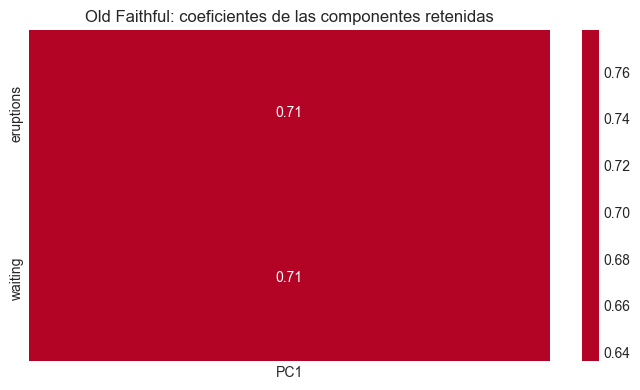

In [15]:
faithful_loadings = pd.DataFrame(faithful_pca.components_.T, index=faithful_features, columns=[f'PC{j+1}' for j in range(len(faithful_ratio))])
display(faithful_loadings.iloc[:, :faithful_n].round(3))
fig, ax = plt.subplots(figsize=(max(7,faithful_n*1.4),4))
sns.heatmap(faithful_loadings.iloc[:, :faithful_n], annot=True, center=0, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Old Faithful: coeficientes de las componentes retenidas');plt.tight_layout();plt.show()


### Scores y proyección en dos dimensiones

El gráfico PC1–PC2 es una vista 2D aunque el umbral requiera más componentes. Las categorías, cuando existen, solo colorean filas tras el ajuste; una separación aparente no valida una clasificación.

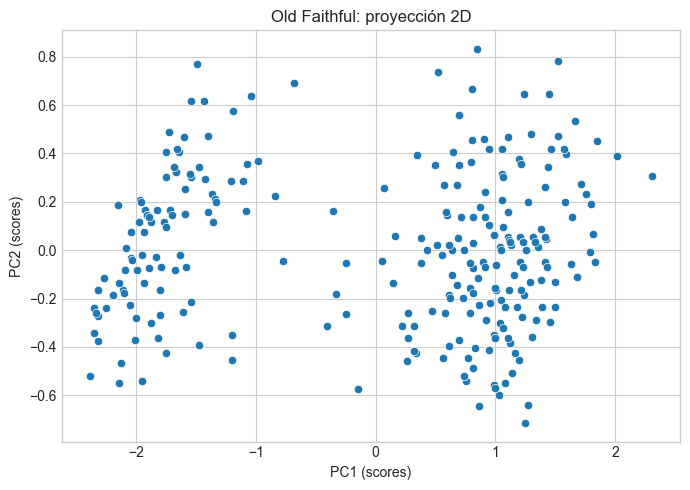

In [16]:
faithful_projection = pd.DataFrame(faithful_scores[:, :2], columns=['PC1','PC2'])
# Las dos medidas originales también permiten contrastar visualmente la rotación de ejes.
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=faithful_projection, x='PC1', y='PC2', ax=ax)
ax.set(xlabel='PC1 (scores)', ylabel='PC2 (scores)', title='Old Faithful: proyección 2D')
plt.tight_layout();plt.show()


### Pérdida al reconstruir

Reconstruimos desde las componentes retenidas y medimos el error cuadrático promedio **en escala estandarizada**. La proyección de dos componentes para graficar y la representación retenida para reconstrucción pueden ser distintas.

In [17]:
faithful_reduced = faithful_scores[:, :faithful_n]
faithful_approx = faithful_reduced @ faithful_pca.components_[:faithful_n, :] + faithful_pca.mean_
faithful_mse = np.mean((faithful_scaled - faithful_approx)**2)
print('Error cuadrático de reconstrucción (escala estandarizada):', round(faithful_mse, 4))


Error cuadrático de reconstrucción (escala estandarizada): 0.0496


**Interpretación guiada de Old Faithful:** compara el porcentaje retenido y el error de reconstrucción con la pregunta inicial. Lee en la tabla de cargas las variables con signo concordante o contrario dentro de cada componente y evita inferir el significado solo por magnitudes absolutas. La importancia de cada dirección depende de la transformación aplicada.

## Caso 3: Wholesale Customers

Cada fila representa un cliente con gastos anuales en seis categorías. ¿Cuántas dimensiones resumen patrones de gasto? Channel y Region se reservan para descripción externa. La fuente requiere conexión.


### Carga y calidad de los datos

Examinamos forma, valores faltantes y rangos antes de escoger y transformar variables. No se eliminan duplicados sin revisar su significado.

In [18]:
wholesale_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv'
wholesale_data = pd.read_csv(wholesale_url)
print('Dimensiones:', wholesale_data.shape)
print('Faltantes:', wholesale_data.isna().sum().to_dict())
display(wholesale_data.head())
display(wholesale_data.describe().round(2))


Dimensiones: (440, 8)
Faltantes: {'Channel': 0, 'Region': 0, 'Fresh': 0, 'Milk': 0, 'Grocery': 0, 'Frozen': 0, 'Detergents_Paper': 0, 'Delicassen': 0}


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00,440.00,440.00
mean,1.32,2.54,12000.30,5796.27,7951.28,3071.93,2881.49,1524.87
std,0.47,0.77,12647.33,7380.38,9503.16,4854.67,4767.85,2820.11
min,1.00,1.00,3.00,55.00,3.00,25.00,3.00,3.00
25%,1.00,2.00,3127.75,1533.00,2153.00,742.25,256.75,408.25
50%,1.00,3.00,8504.00,3627.00,4755.50,1526.00,816.50,965.50
75%,2.00,3.00,16933.75,7190.25,10655.75,3554.25,3922.00,1820.25
max,2.00,3.00,112151.00,73498.00,92780.00,60869.00,40827.00,47943.00


### Selección de variables

Elegimos mediciones continuas que describen el fenómeno. Excluimos etiquetas, identificadores y categorías externas del ajuste; las categorías se pueden usar después para colorear el gráfico.

In [19]:
wholesale_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
wholesale_X = wholesale_data[wholesale_features].copy()
display(wholesale_X.corr().round(2))


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.00,0.10,-0.01,0.35,-0.10,0.24
Milk,0.10,1.00,0.73,0.12,0.66,0.41
Grocery,-0.01,0.73,1.00,-0.04,0.92,0.21
Frozen,0.35,0.12,-0.04,1.00,-0.13,0.39
Detergents_Paper,-0.10,0.66,0.92,-0.13,1.00,0.07
Delicassen,0.24,0.41,0.21,0.39,0.07,1.00


**Decisión de preparación:** el gasto es positivo y muy asimétrico; `log1p` comprime extremos antes de estandarizar. Las cargas describirán el gasto transformado, no variaciones monetarias lineales.

### Escala y representación para el modelo

Ajustamos el escalador únicamente sobre las variables elegidas. La tabla original se conserva para interpretar los resultados.

In [20]:
wholesale_processed = np.log1p(wholesale_X)
wholesale_scaler = StandardScaler()
wholesale_scaled = wholesale_scaler.fit_transform(wholesale_processed)
display(pd.DataFrame(wholesale_scaled, columns=wholesale_features).describe().loc[['mean', 'std']].round(2))


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
mean,0.0,-0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


### Ajuste del PCA completo

`fit_transform` calcula las direcciones y proyecta las observaciones. Ajustamos inicialmente todas las componentes para observar la varianza de cada una antes de decidir cuántas retener.

In [21]:
wholesale_pca = PCA()
wholesale_scores = wholesale_pca.fit_transform(wholesale_scaled)
wholesale_ratio = wholesale_pca.explained_variance_ratio_
wholesale_cumulative = np.cumsum(wholesale_ratio)
wholesale_variance = pd.DataFrame({'componente': np.arange(1, len(wholesale_ratio)+1), 'varianza': wholesale_ratio, 'acumulada': wholesale_cumulative})
display(wholesale_variance.round(3))


,componente,varianza,acumulada
0,1,0.441,0.441
1,2,0.272,0.713
2,3,0.107,0.820
3,4,0.101,0.921
4,5,0.049,0.970
5,6,0.030,1.000


### Selección gráfica de componentes

El scree plot muestra ganancias individuales y la curva acumulada señala el menor número de componentes que alcanza el 80 %. Esta elección orienta una reducción; si importa una variable de baja varianza, se debe revisar con el objetivo de análisis.

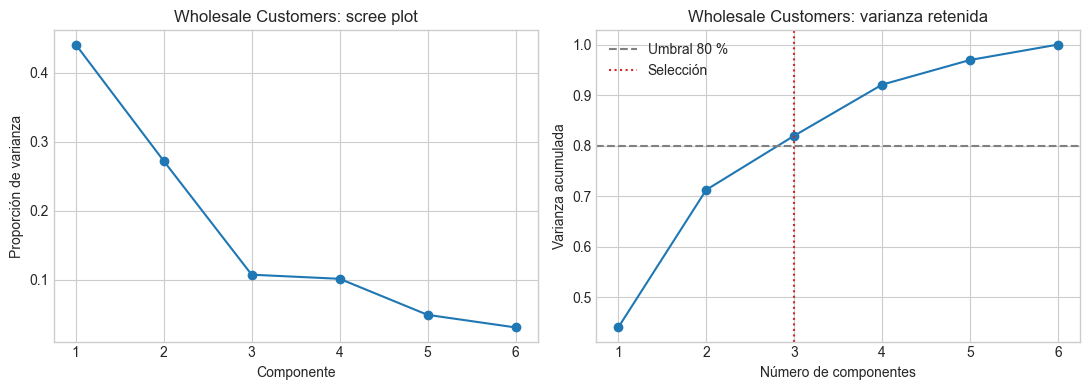

Componentes retenidas: 3 Varianza conservada: 0.82


In [22]:
wholesale_n = int(np.searchsorted(wholesale_cumulative, VARIANCE_TARGET) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(wholesale_variance.componente, wholesale_ratio, marker='o')
axes[0].set(xlabel='Componente', ylabel='Proporción de varianza', title='Wholesale Customers: scree plot')
axes[1].plot(wholesale_variance.componente, wholesale_cumulative, marker='o')
axes[1].axhline(VARIANCE_TARGET, color='gray', linestyle='--', label='Umbral 80 %')
axes[1].axvline(wholesale_n, color='tab:red', linestyle=':', label='Selección')
axes[1].set(xlabel='Número de componentes', ylabel='Varianza acumulada', title='Wholesale Customers: varianza retenida')
axes[1].legend();plt.tight_layout();plt.show()
print('Componentes retenidas:', wholesale_n, 'Varianza conservada:', round(wholesale_cumulative[wholesale_n-1], 3))


### Cargas y estructura de las variables

Las direcciones (`components_.T`) dan los coeficientes sobre las variables estandarizadas. Su magnitud relativa identifica variables influyentes y los signos **relativos dentro de una componente** distinguen covariación y contraste. No asignamos significado automático basándonos únicamente en el ranking absoluto.

,PC1,PC2,PC3
Fresh,-0.105,0.590,-0.640
Milk,0.542,0.133,-0.074
Grocery,0.571,-0.006,-0.133
Frozen,-0.138,0.590,-0.021
Detergents_Paper,0.551,-0.071,-0.200
Delicassen,0.214,0.530,0.726


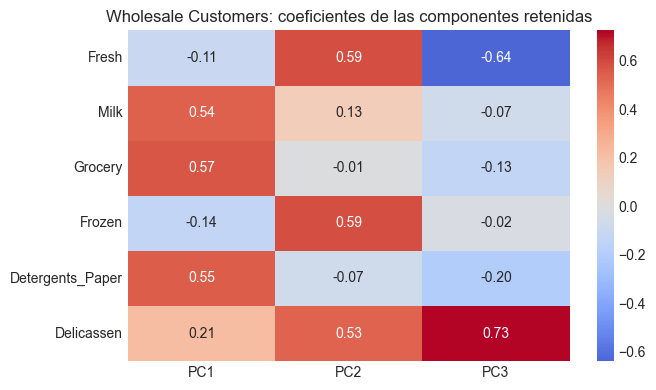

In [23]:
wholesale_loadings = pd.DataFrame(wholesale_pca.components_.T, index=wholesale_features, columns=[f'PC{j+1}' for j in range(len(wholesale_ratio))])
display(wholesale_loadings.iloc[:, :wholesale_n].round(3))
fig, ax = plt.subplots(figsize=(max(7,wholesale_n*1.4),4))
sns.heatmap(wholesale_loadings.iloc[:, :wholesale_n], annot=True, center=0, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Wholesale Customers: coeficientes de las componentes retenidas');plt.tight_layout();plt.show()


### Scores y proyección en dos dimensiones

El gráfico PC1–PC2 es una vista 2D aunque el umbral requiera más componentes. Las categorías, cuando existen, solo colorean filas tras el ajuste; una separación aparente no valida una clasificación.

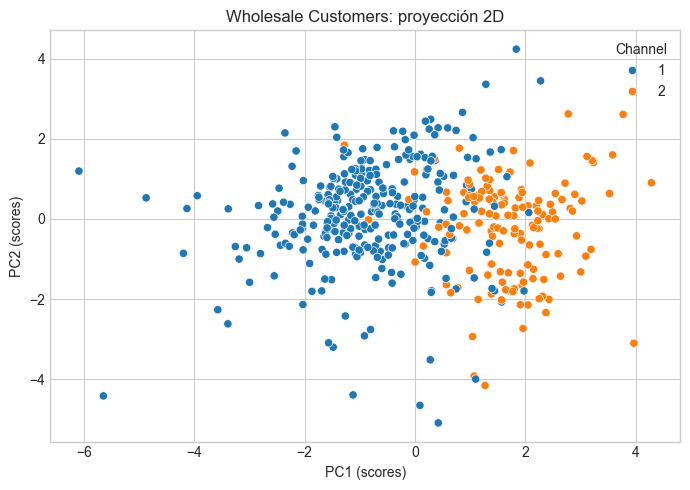

In [24]:
wholesale_projection = pd.DataFrame(wholesale_scores[:, :2], columns=['PC1','PC2'])
wholesale_projection['Channel'] = wholesale_data['Channel'].to_numpy()
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=wholesale_projection, x='PC1', y='PC2', hue='Channel', palette='tab10', ax=ax)
ax.set(xlabel='PC1 (scores)', ylabel='PC2 (scores)', title='Wholesale Customers: proyección 2D')
plt.tight_layout();plt.show()


### Pérdida al reconstruir

Reconstruimos desde las componentes retenidas y medimos el error cuadrático promedio **en escala estandarizada**. La proyección de dos componentes para graficar y la representación retenida para reconstrucción pueden ser distintas.

In [25]:
wholesale_reduced = wholesale_scores[:, :wholesale_n]
wholesale_approx = wholesale_reduced @ wholesale_pca.components_[:wholesale_n, :] + wholesale_pca.mean_
wholesale_mse = np.mean((wholesale_scaled - wholesale_approx)**2)
print('Error cuadrático de reconstrucción (escala estandarizada):', round(wholesale_mse, 4))


Error cuadrático de reconstrucción (escala estandarizada): 0.1803


**Interpretación guiada de Wholesale Customers:** compara el porcentaje retenido y el error de reconstrucción con la pregunta inicial. Lee en la tabla de cargas las variables con signo concordante o contrario dentro de cada componente y evita inferir el significado solo por magnitudes absolutas. La importancia de cada dirección depende de la transformación aplicada.

## Comparación y limitaciones

Compara los tres porcentajes retenidos para observar cómo correlación y número de variables afectan la compresión. PCA maximiza varianza total de la representación elegida: depende de escala, transformaciones y valores extremos; no separa necesariamente grupos ni identifica causas o factores latentes. Un 80 % de varianza no asegura mantener señales de poca varianza importantes para otra tarea.


## Ejercicios propuestos

1. **Conceptual:** explica por qué PC1 puede mezclar tamaño y composición de gastos.
2. **Experimentación:** repite la elección con umbrales de 70 % y 95 %; compara error de reconstrucción.
3. **Código:** aplica PCA sin estandarizar a Iris; compara las cargas con el ajuste original.
4. **Interpretación:** identifica un contraste de signos entre variables y explica qué significa sin fijarse en el signo global arbitrario.
5. **Transferencia:** distingue una proyección 2D exploratoria de las dimensiones retenidas para otro modelo.


## Referencias y fuentes

- Scikit-learn, `PCA` y dataset Iris.
- Rdatasets, `faithful` (datos de R).
- UCI Machine Learning Repository, Wholesale Customers (dataset 292).
